## MATH 151 Lab  6

Justus Languell, Kyle Miller, Dennis Hodgkins

In [5]:
import sympy as sp
from sympy.plotting import (plot,plot_parametric, plot_implicit)

### Question 1

#### 1a

In [70]:
t = sp.symbols('t')
xoft = 2 + 4 * (sp.sin(t) ** 3)
yoft =  2 + 4 * (sp.cos(t) ** 3)

xp = sp.diff(xoft, t)
yp = sp.diff(yoft, t)
dydx = yp / xp

t0 = sp.pi / 4

m = dydx.subs(t, t0)

x0 = xoft.subs(t, t0)
y0 = yoft.subs(t, t0)

x = sp.symbols('x')
y = sp.symbols('y')

tanline_1a = m * (x - x0) + y0

print("The tangent line at the point where t=pi/4 is")
display(sp.Eq(y, tanline_1a))

The tangent line at the point where t=pi/4 is


Eq(y, -x + 2*sqrt(2) + 4)

#### 1b

In [71]:
target_dydx = 2

t_solutions = sp.solveset(sp.Eq(target_dydx, dydx), t, domain=sp.Interval(0,2*sp.pi)) # Period of y' is < 2pi. Refer to the note above
# print('Horizontal tangents when t=', t_solutions)

points = [(xoft.subs(t, t_solution), yoft.subs(t, t_solution)) for t_solution in t_solutions]

for xT, yT in points:
    display(sp.Point(xT, yT))

Point2D(4*sqrt(5)/25 + 2, 2 - 32*sqrt(5)/25)

Point2D(2 - 4*sqrt(5)/25, 2 + 32*sqrt(5)/25)

#### 1c

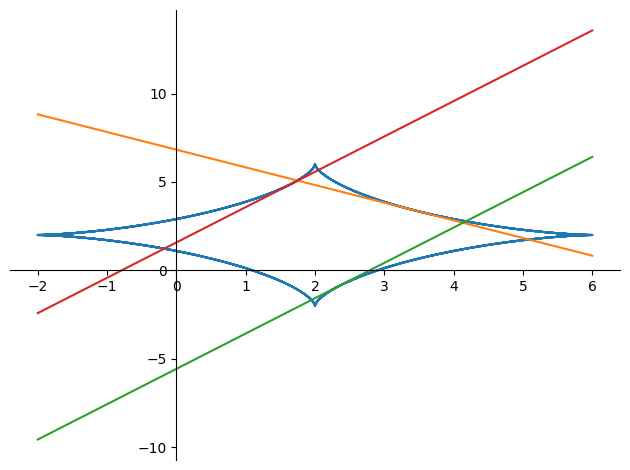

In [72]:
plots = plot_parametric(xoft, yoft, (t, 0, 8*sp.pi), show=False)

plots.append(plot(tanline_1a, (x, -2, 6), show=False)[0])

for xT, yT in points:
    f_target_dydx = target_dydx * (x - xT) + yT
    plots.append(plot(f_target_dydx, (x, -2, 6), show=False)[0])

plots.show()

### Question 2

#### 2a

In [3]:
x, y = sp.symbols('x y')
Left = (2*x*y)*(x**2 - y**2)
Right = x**2 + y**2
eqn = ((2*x*y)*(x**2 - y**2))-(x**2 + y**2)
dy_dx = sp.idiff(Left - Right, y, x)
display(dy_dx)

(-3*x**2*y + x + y**3)/(x**3 - 3*x*y**2 - y)

#### 2b

In [20]:
numerator = sp.numer(dy_dx)
h_sols  = sp.solve([numerator, eqn], [x, y])
print('There are horizontal tangents at:')

real_h_sols = []
for x_sol, y_sol in h_sols:
    try:
        if x_sol == y_sol == 0: continue # ignore the (0, 0) case
        display(sp.Point(x_sol, y_sol))
        real_h_sols.append((x_sol, y_sol))
    except ValueError as e:
        pass # imaginary solution, ignore

There are horizontal tangents at:


Point2D((-7/8 + 3*sqrt(5)/8)*(22 + 10*sqrt(5))**(3/4), 2**(1/4)*(11 + 5*sqrt(5))**(1/4)/2)

Point2D((7/8 - 3*sqrt(5)/8)*(22 + 10*sqrt(5))**(3/4), -2**(1/4)*(11 + 5*sqrt(5))**(1/4)/2)

#### 2c

In [25]:
denom = sp.denom(dy_dx)
v_sols = sp.solve([denom, eqn],[x,y])
print('There are vertical tangents at:')

real_v_sols = []
for x_sol, y_sol in v_sols:
    try:
        if x_sol == y_sol == 0: continue # ignore the (0, 0) case
        display(sp.Point(x_sol, y_sol))
        real_v_sols.append((x_sol, y_sol))
    except ValueError as e:
        pass # imaginary solution, ignore

There are vertical tangents at:


Point2D(2**(3/4)*(1 + sqrt(5))/(4*(-1 + sqrt(5))**(1/4)), 2**(1/4)*(-1 + sqrt(5))**(1/4)/2)

Point2D(2**(3/4)*(-sqrt(5) - 1)/(4*(-1 + sqrt(5))**(1/4)), -2**(1/4)*(-1 + sqrt(5))**(1/4)/2)

#### 2d

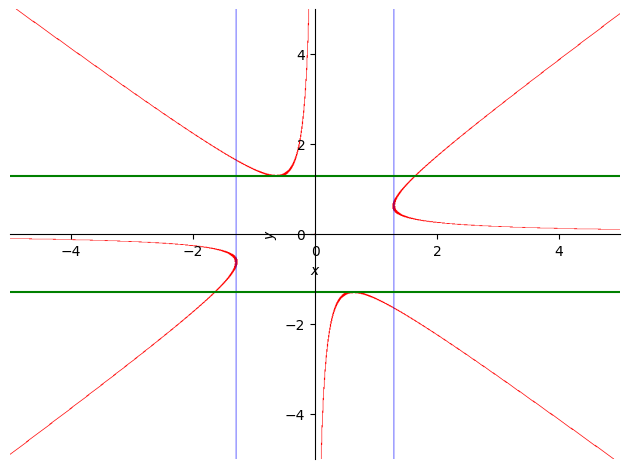

In [34]:
plots = plot_implicit(Left-Right, x, y, show=False, line_color='red')

for x_sol, _ in real_v_sols:
    plots.append(plot_implicit(sp.Eq(x, x_sol.evalf()), line_color='blue', show=False)[0])

for _, y_sol in real_h_sols:
    plots.append(plot(y_sol.evalf(), show=False, line_color='green')[0])

plots.show()

### Question 3

#### 3a

In [22]:
yn = sp.symbols("yn")
r = sp.Symbol("r", real=True)

vars = sp.solve([yn * sp.E**(r * 2) - 50000, yn * sp.E**(r * 6) - 60000], [yn, r])
yn = vars[0][0]
r = vars[0][1]
print(f"y0 = {yn}")
print(f"r  = {r} = {r.evalf()}")

y0 = 25000*sqrt(30)/3
r  = -log(5)/4 + log(6)/4 = 0.0455803891984887


#### 3b

In [23]:
time = sp.solve(yn * sp.E**(r * t) - 75000)
print(f"{time[0]}, or {time[0].evalf()}, years")

-log((3*sqrt(30)/10)**(4/log(5/6))), or 10.8956043429662, years


#### 3c

In [24]:
rNew = sp.Symbol("rNew", real="True")
rNew = sp.solve(50000 * sp.E**(rNew * 4) - 60000, rNew)[0]
print(f"r = {rNew} = {rNew.evalf()}")

tnNew = 50000 * sp.E**(rNew * -2)
print(f"t = {tnNew}")

print("The r and t values appear identical in both parts. This is due to both parts using an equation based off the")
print("same two points on an exponential growth curve. The only difference is starting year assigned to the model.")

r = log(5**(3/4)*6**(1/4)/5) = 0.0455803891984887
t = 25000*sqrt(30)/3
The r and t values appear identical in both parts. This is due to both parts using an equation based off the
same two points on an exponential growth curve. The only difference is starting year assigned to the model.
